<a href="https://colab.research.google.com/github/iconrealestate77/synthetichandwriting/blob/main/01_cGAN_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# cGAN Training

### Goal - To build and train our **conditional GAN (cGAN)** - a generative model that learsn to create **synthetic handwriting images** conditioned on digit labels

## Plan

1. Understand the architecture of a **conditional Gan (cGAN)**
2. Implement **Generator** and **discriminator** in pytorch
3. Train model with adversarial objectives
4. Visualise class-conditional handwriting samples

## Recap (cGAN)

A **Generative Adversarial Network (GAN)** consists of:
- A **Generator (G)** that creates fake samples from random noise.
- A **Discriminator (D)** that tries to tell real from fake.

In a **Conditional GAN**, both G and D receive an **additional input**: a *class label*.  
This allows the model to generate specific digits or characters on demand.

In [ ]:
!git clone https://github.com/iconrealestate77/synthetichandwriting.git /content/synthetichandwriting
%cd /content/synthetichandwriting/starter


Cloning into '/content/synthetichandwriting'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 20 (delta 0), reused 20 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 19.32 KiB | 3.86 MiB/s, done.
/content/synthetichandwriting/starter


In [ ]:
%cd /content/synthetichandwriting/starter


/content/synthetichandwriting/starter


In [ ]:
# import core libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

import os, sys

from data_utils.dataloader import get_mnist_loaders
from model.cgan import Generator, Discriminator
from utils.visualize import show_batch
from utils.checkpoint import save_checkpoint

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Running on device: {device}")

 Running on device: cpu


### Define Model Hyperparameters


We’ll use a low-dimensional latent space (`z_dim = 100`),  
and condition the model on **10 digit classes (0–9)**.

GANs are notoriously sensitive to hyperparameters —  
we’ll start simple and iterate.

In [ ]:
# hyperparameters
z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)
batch_size = 128
lr = 0.0002
epochs = 50

In [ ]:
#ToDO: extract the data
#Tip: Use the `get_mnist_loader` function in dataloader.py
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader, test_loader = get_mnist_loaders(batch_size=batch_size, transform=transform)
print(f"Training batches: {len(train_loader)} | Test batches: {len(test_loader)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 64.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.80MB/s]

Training batches: 469 | Test batches: 79


Before we dive into training, let's define both our **Generator** and **Discriminator**.

Each will use the label embedding trick — where we turn the class label (e.g., “3”) into a learnable vector that can be concatenated with the noise or image input.

Our models are intentionally **lightweight** to make training on CPU/MPS feasible.  We’ll focus on the learning process and class conditioning rather than pixel-perfect realism.

In [ ]:
##ToDo: initialize models and optimizers
generator = Generator(z_dim=z_dim, num_classes=num_classes, img_shape=img_shape).to(device)
discriminator = Discriminator(num_classes=num_classes, img_shape=img_shape).to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))


## Training Strategy

We’ll alternate between training the **Discriminator (D)** and **Generator (G)**.

1. **Train D:**  
   - Use real images labeled as 1  
   - Use fake images (from G) labeled as 0  

2. **Train G:**  
   - Generate fake images  
   - Fool D into predicting them as 1  

This adversarial game continues until G generates *realistic*, class-conditioned digits.

In [ ]:
!ls training


__pycache__  train_cgan.py  train_diffusion.py


In [28]:
import importlib
import training.train_cgan
importlib.reload(training.train_cgan)
from training.train_cgan import train_cgan


In [ ]:
!touch training/__init__.py


In [ ]:
!mkdir -p checkpoints


In [ ]:
%%writefile training/train_cgan.py
"""
train_cgan.py
-------------
Reusable training function for cGAN experiments.
"""

import torch


def train_cgan(
    generator,
    discriminator,
    dataloader,
    optimizer_G,
    optimizer_D,
    criterion,
    device,
    z_dim,
    num_classes,
    epochs=50,
):
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            batch_size = imgs.size(0)

            valid = torch.ones(batch_size, 1).to(device)
            fake = torch.zeros(batch_size, 1).to(device)

            # Train Generator
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, z_dim).to(device)
            gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
            gen_imgs = generator(z, gen_labels)
            g_loss = criterion(discriminator(gen_imgs, gen_labels), valid)
            g_loss.backward()
            optimizer_G.step()

            # Train Discriminator
            optimizer_D.zero_grad()
            real_loss = criterion(discriminator(imgs, labels), valid)
            fake_loss = criterion(discriminator(gen_imgs.detach(), gen_labels), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

        print(
            f"[Epoch {epoch+1}/{epochs}] D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}"
        )

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save(
                generator.state_dict(), f"checkpoints/generator_epoch{epoch+1}.pt"
            )
            torch.save(
                discriminator.state_dict(),
                f"checkpoints/discriminator_epoch{epoch+1}.pt",
            )
            print(f"Saved checkpoints at epoch {epoch+1}")


Overwriting training/train_cgan.py


In [ ]:
#ToDo:
     # 1.  Implement training loop
     # 2. Save D & G every 10 epochs
from training.train_cgan import train_cgan

train_cgan(
    generator=generator,
    discriminator=discriminator,
    dataloader=train_loader,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    criterion=criterion,
    device=device,
    z_dim=z_dim,
    num_classes=num_classes,
    epochs=epochs,
)


[Epoch 1/50] D loss: 0.2376 | G loss: 2.2374
[Epoch 2/50] D loss: 0.1873 | G loss: 2.0900
[Epoch 3/50] D loss: 0.1839 | G loss: 1.7968
[Epoch 4/50] D loss: 0.4512 | G loss: 0.7774
[Epoch 5/50] D loss: 0.2344 | G loss: 1.9366
[Epoch 6/50] D loss: 0.3628 | G loss: 5.2466
[Epoch 7/50] D loss: 0.1539 | G loss: 2.1413
[Epoch 8/50] D loss: 0.3423 | G loss: 3.8092
[Epoch 9/50] D loss: 0.1635 | G loss: 2.6606
[Epoch 10/50] D loss: 0.2207 | G loss: 4.7093
Saved checkpoints at epoch 10
[Epoch 11/50] D loss: 0.1452 | G loss: 2.0743
[Epoch 12/50] D loss: 0.3329 | G loss: 1.2218
[Epoch 13/50] D loss: 0.1825 | G loss: 1.9246
[Epoch 14/50] D loss: 0.1938 | G loss: 1.8722
[Epoch 15/50] D loss: 0.4199 | G loss: 3.8422
[Epoch 16/50] D loss: 0.1491 | G loss: 2.3197
[Epoch 17/50] D loss: 0.0821 | G loss: 2.7070
[Epoch 18/50] D loss: 0.2047 | G loss: 1.7717
[Epoch 19/50] D loss: 0.3667 | G loss: 6.2763
[Epoch 20/50] D loss: 0.2055 | G loss: 2.6486
Saved checkpoints at epoch 20
[Epoch 21/50] D loss: 0.2256 

In [30]:
!ls checkpoints


discriminator_epoch10.pt  discriminator_epoch50.pt  generator_epoch40.pt
discriminator_epoch20.pt  generator_epoch10.pt	    generator_epoch50.pt
discriminator_epoch30.pt  generator_epoch20.pt
discriminator_epoch40.pt  generator_epoch30.pt


In [31]:
# ToDo: Save Final Model
save_checkpoint(generator, optimizer_G, epoch=epochs, loss=None, name="cgan_generator_final")
save_checkpoint(discriminator, optimizer_D, epoch=epochs, loss=None, name="cgan_discriminator_final")
print("Final cGAN generator and discriminator checkpoints saved.")


Saved checkpoint: ../checkpoints/cgan_generator_final_epoch50.pt
Saved checkpoint: ../checkpoints/cgan_discriminator_final_epoch50.pt
Final cGAN generator and discriminator checkpoints saved.


### Note
Training GANs can be unstable.  
If losses oscillate, that’s expected — D and G are in constant competition.

Let’s visualize a few generated samples at the end of training to check if conditioning worked.

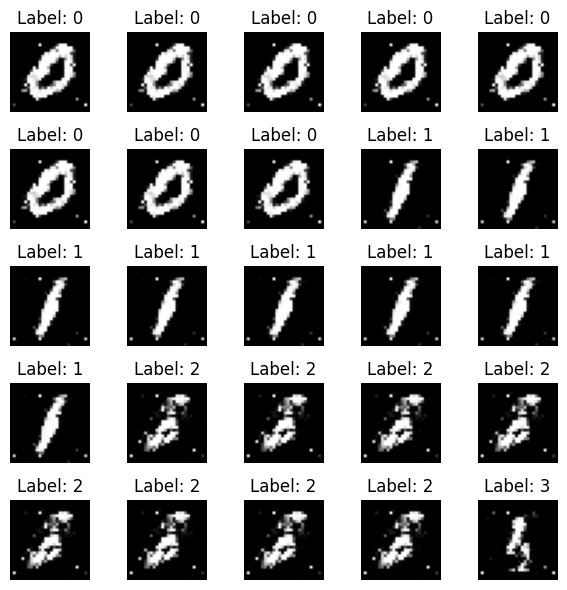

In [32]:
### Generate and visualize samples
def generate_samples(generator, n_classes=10, n_per_class=8):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_classes * n_per_class, z_dim).to(device)
        labels = torch.tensor([i for i in range(n_classes) for _ in range(n_per_class)]).to(device)
        gen_imgs = generator(z, labels)
    generator.train()
    return gen_imgs, labels

gen_imgs, gen_labels = generate_samples(generator)
show_batch(gen_imgs.cpu(), gen_labels.cpu(), n=25)

We can now see grids of digits 0–9, each set showing several synthetic examples.  
Each class label corresponds to the digit the Generator was conditioned on.

Even if the images look a bit fuzzy, the model has learned the *concept* of conditioning —  
the generator “knows” which class to produce.